## Setting things up

### Import libraries
Add directory with the CIBUSmod modules to path to be able to import

In [1]:
import sys
import os
sys.path.insert(0, 'C:\\Users/jnka0003/Git repos/CIBUSmod')

Import CIBUSmod and packages for handling data and plotting

In [2]:
import CIBUSmod as cm

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Set up scenarios

In [8]:
# Create session
session = cm.Session(
    name = 'FORMAS', # <--- Make sure that name and data_path match with multi_proc.py
    data_path = 'C:\\Users/jnka0003/Git repos/CIBUSmod/data',
    data_path_scenarios = 'scenarios',
    data_path_output = 'output',
)
# cm.ParameterRetriever.data_path_scenarios = os.path.join('scenarios')

# Define scenarios

session.add_scenario(
    name = 'BL',
    scenario_workbooks = None, 
    modules = 'all',
    pars = 'all',
    years = 0
)
session.add_scenario(
    name = 'MAX_CUR',
    scenario_workbooks = 'sng_area', 
    modules = 'all',
    pars = 'all',
    years = [70, 100, 110]
)
session.add_scenario(
    name = 'STEERS',
    scenario_workbooks = ['sng_area', 'STEERS'], 
    modules = 'all',
    pars = 'all',
    years = [70, 100, 110]
)
session.add_scenario(
    name = 'RET_COWS',
    scenario_workbooks = ['sng_area', 'RET_COWS'], 
    modules = 'all',
    pars = 'all',
    years = [70, 100, 110]
)
session.add_scenario(
    name = 'WIN_LAMB',
    scenario_workbooks = ['sng_area', 'WIN_LAMB'], 
    modules = 'all',
    pars = 'all',
    years = [70, 100, 110]
)
session.add_scenario(
    name = 'REC_HORSES',
    scenario_workbooks = ['sng_area', 'REC_HORSES'], 
    modules = 'all',
    pars = 'all',
    years = [70, 100, 110]
)
session.add_scenario(
    name = 'ALL',
    scenario_workbooks = ['sng_area', 'STEERS', 'RET_COWS', 'WIN_LAMB', 'REC_HORSES'], 
    modules = 'all',
    pars = 'all',
    years = [70, 100, 110]
)

A scenario with the name 'BL' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'MAX_CUR' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'STEERS' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'RET_COWS' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'WIN_LAMB' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'REC_HORSES' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'ALL' already exists use .update_scenario() or .remove_scenario() instead.


## Plot results

In [9]:
# Common style for plots
bar_style = {
    'cmap' : 'Pastel1',
    'edgecolor' : 'grey',
    'bar_width' : 0.6
}

bar_style_one = {
    'color' : 'lightgrey',
    'edgecolor' : 'grey'
}

map_style = {
    'cmap' : 'YlOrBr',
    'edgecolor' : 'grey'
}

map_style_r = map_style.copy()
map_style_r['cmap'] = map_style_r['cmap'] + '_r'

map_style_div = {
    'cmap' : 'BrBG',
    'edgecolor' : 'grey'
}

# Get final iteration of each scenario
scn_final = [(scn, '110' if '110' in years else '0') for scn, years in session.scenarios('has output').items()]

rename_years = {
    '0' : '',
    '70' : '-30% CH4',
    '100' : '+/-0% CH4',
    '110' : '+10% CH4'
}

# Scenario sort
sort = (
    session.get_attr('c','area',{'crop':['land_use',None]})
    .loc[:,'semi-natural grasslands']
    .rename(rename_years)
    .sum(axis=1)
    .sort_values()
    .index
)

def _legend_r(ax):  
    ax.legend(loc='center left', bbox_to_anchor=(1,0.5), frameon=False, ncol=1, fontsize=9, reverse=True)
def _legend_t(ax):  
    ax.legend(loc='lower center', bbox_to_anchor=(0.5,1.3), frameon=False, ncol=2, fontsize=9, reverse=True)

### Bars: Main results

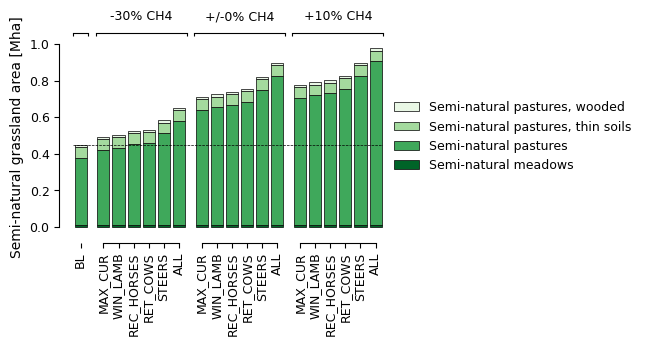

In [10]:
# SNG AREA ---------------------------------------------------------------------- ##
fig, ax = plt.subplots(figsize=(4,2.4))
plot_data = (
    session.get_attr('c','area',{'crop':['land_use',None]})
    .loc[:,'semi-natural grasslands']
    .rename(rename_years)
)/1000000

cm.plot.bar(
    plot_data.loc[sort],
    ax=ax,
    group_levels='year',
    sort_xlabels=False,
    sort_groups=False,
    cmap='Greens',
    ylabel='Semi-natural grassland area [Mha]',
    ylabel_fontsize=10,
    grouplabels_fontsize=9,
    ticklabels_fontsize=9
)
ax.axhline(plot_data.loc[('BL','')].sum(), c='black', linewidth=0.5, linestyle='--')
_legend_r(ax)

plt.show()

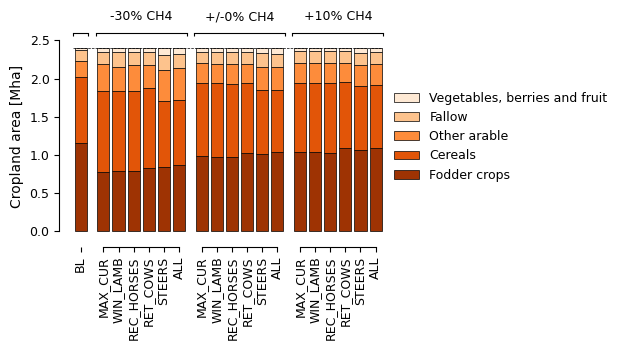

In [11]:
# CROP AREA ---------------------------------------------------------------------- ##

fig, ax = plt.subplots(figsize=(4,2.5))
plot_data = (
    session.get_attr('c','area',{'crop':['land_use','crop_group2']})
    .loc[:,'cropland']
    .rename(rename_years)
)/1000000
cm.plot.bar(
    plot_data.loc[sort],
    ax=ax,
    sort_categories=True,
    group_levels='year',
    cmap='Oranges',
    ylabel='Cropland area [Mha]',
    ylabel_fontsize=10,
    grouplabels_fontsize=9,
    ticklabels_fontsize=9
)
ax.axhline(plot_data.loc[('BL','')].sum(), c='black', linewidth=0.5, linestyle='--')
_legend_r(ax)

plt.show()

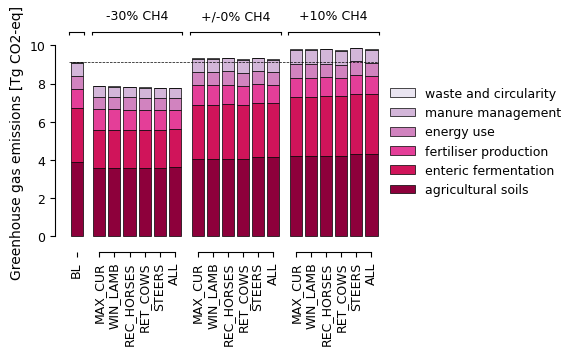

In [12]:
# GHG ---------------------------------------------------------------------- ##

fig, ax = plt.subplots(figsize=(4,2.5))
plot_data = (
    cm.get_GHG(session, CO2eq = True)
    .T.groupby('process').sum().T
    .rename(rename_years)
)/1000000000
cm.plot.bar(
    plot_data.loc[sort],
    ax=ax,
    sort_categories=True,
    group_levels='year',
    cmap='PuRd',
    ylabel='Greenhouse gas emissions [Tg CO2-eq]',
    ylabel_fontsize=10,
    grouplabels_fontsize=9,
    ticklabels_fontsize=9
)
ax.axhline(plot_data.loc[('BL','')].sum(), c='black', linewidth=0.5, linestyle='--')
_legend_r(ax)

plt.show()

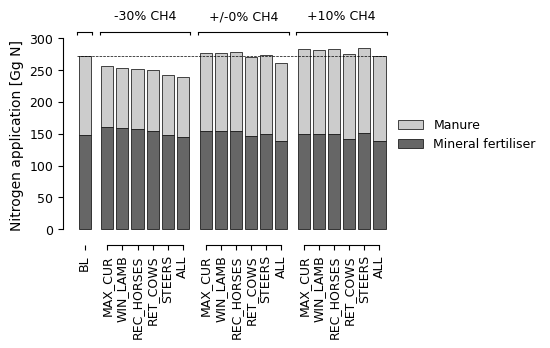

In [13]:
# N FERTILISER ---------------------------------------------------------------------- ##

fig, ax = plt.subplots(figsize=(4,2.5))
plot_data = (
    pd.concat([
        session.get_attr('c','fertiliser.mineral_N', 'none').rename('Mineral fertiliser'),
        session.get_attr('c','fertiliser.manure_N', 'none').rename('Manure')
    ], axis=1)
    .rename(rename_years)
)/1000000
from matplotlib.colors import ListedColormap
cm.plot.bar(
    plot_data.loc[sort],
    ax=ax,
    sort_categories=True,
    group_levels='year',
    cmap=ListedColormap(name='X', colors=['#666666','#cccccc']),
    ylabel='Nitrogen application [Gg N]',
    ylabel_fontsize=10,
    grouplabels_fontsize=9,
    ticklabels_fontsize=9
)
ax.axhline(plot_data.loc[('BL','')].sum(), c='black', linewidth=0.5, linestyle='--')
_legend_r(ax)

plt.show()

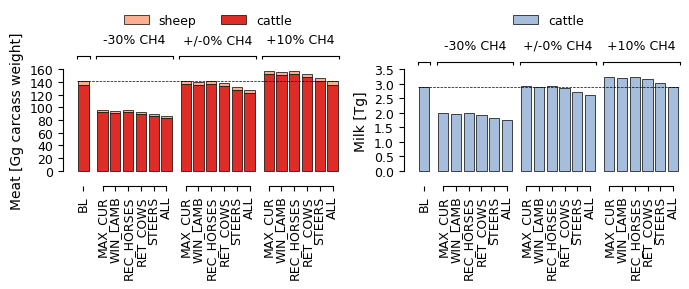

In [14]:
# MEAT AND MILK ---------------------------------------------------------------------- ##
fig, axs = plt.subplots(1,2, figsize=(7,3.5))
plot_data = (
    session.get_attr('a','prod', ['animal_prod','species'])
    .loc[:,(slice(None),['cattle','sheep'])]
    .rename(rename_years)
)/1000000
ax = axs[0]
cm.plot.bar(
    plot_data.loc[:,'meat'].loc[sort],
    ax=ax,
    sort_categories=True,
    group_levels='year',
    cmap=ListedColormap(name='X', colors=['#de2d26','#fcae91']),
    ylabel='Meat [Gg carcass weight]',
    ylabel_fontsize=10,
    grouplabels_fontsize=9,
    ticklabels_fontsize=9
)
ax.axhline(plot_data.loc[('BL',''),'meat'].sum(), c='black', linewidth=0.5, linestyle='--')
_legend_t(ax)
ax = axs[1]
cm.plot.bar(
    plot_data.loc[:,'milk'].loc[sort]/1000,
    ax=ax,
    sort_categories=True,
    group_levels='year',
    cmap=ListedColormap(name='X', colors=['#a6bddb']),
    ylabel='Milk [Tg]',
    ylabel_fontsize=10,
    grouplabels_fontsize=9,
    ticklabels_fontsize=9
)
ax.axhline(plot_data.loc[('BL',''),'milk'].sum()/1000, c='black', linewidth=0.5, linestyle='--')
_legend_t(ax)

plt.tight_layout()
plt.show()

### Bars: Grazing

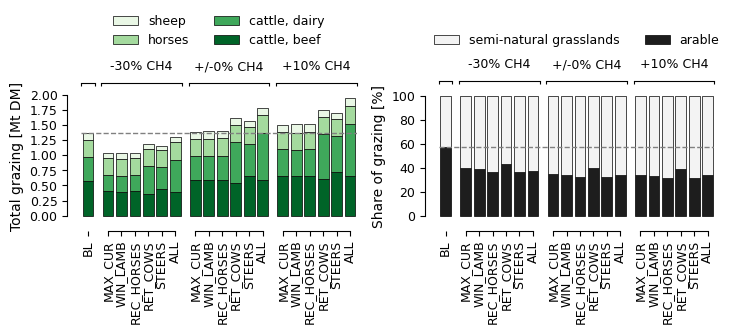

In [15]:
d1 = (
    session
    .get_attr('a','feed.crop_product_demand',['crop_prod','species','breed'])
    .loc[:,'grazing']
    .rename(rename_years)
    .loc[sort]
    /1_000_000_000
)
d1.columns = pd.Index([c[0] if c[0] != 'cattle' else ', '.join(c) for c in d1.columns], name='animal_system')
d1 = d1.T.groupby('animal_system').sum().T

d2 = (
    session
    .get_attr('c','production',{'crop_prod':None, 'crop':'land_use'})
    .loc[:,'grazing']
    .apply(lambda x: x/x.sum()*100, axis=1)
    .rename(rename_years)
    .rename(columns={'cropland':'arable'})
    .loc[sort]
)

fig,axs = plt.subplots(1,2, figsize=(7.5,4))
ax = axs[0]
cm.plot.bar(
    d1,
    group_levels='year',
    cmap='Greens',
    ylabel='Total grazing [Mt DM]',
    ylabel_fontsize=10,
    ticklabels_fontsize=9,
    grouplabels_fontsize=9,
    ax=ax
)
ax.axhline(y=d1.sum(axis=1).loc['BL'].iloc[0], linestyle='--', linewidth=1, color='grey')

ax = axs[1]
cm.plot.bar(
    d2,
    group_levels='year',
    cmap='Greys',
    ylabel='Share of grazing [%]',
    ylabel_fontsize=10,
    ticklabels_fontsize=9,
    grouplabels_fontsize=9,
    ax=ax
)
ax.axhline(y=d2.loc['BL','arable'].iloc[0], linestyle='--', linewidth=1, color='grey')

for ax in axs.flatten():
    _legend_t(ax)

plt.tight_layout()
plt.show()

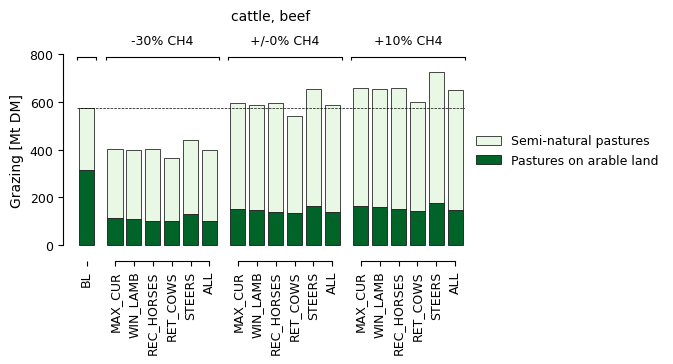

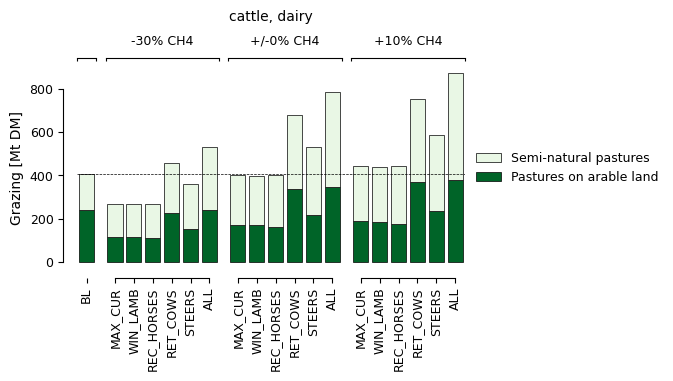

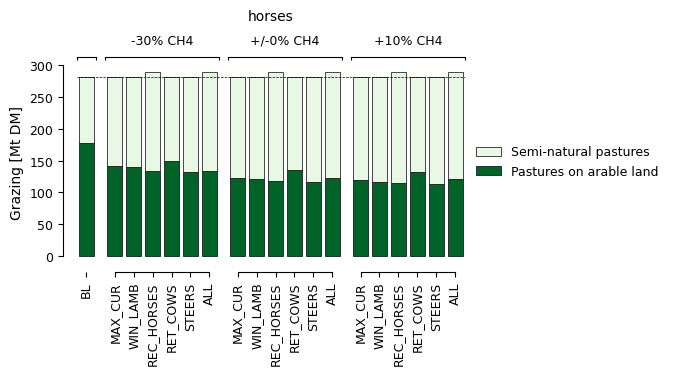

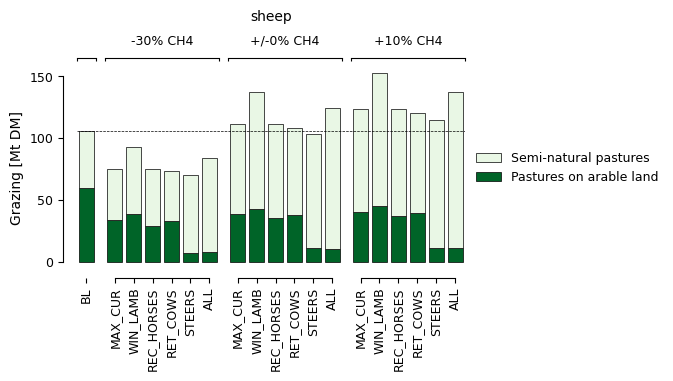

In [16]:
rename_crp = {
    'Ley for grazing' : 'Pastures on arable land',
    'Semi-natural pastures' : 'Semi-natural pastures',
    'Semi-natural pastures, thin soils' : 'Semi-natural pastures',
    'Semi-natural pastures, wooded' : 'Semi-natural pastures'
}

plot_data = (
    session.get_attr('c','production_per_use', ['crop', 'demand'])
    .rename(rename_years)
    .loc[sort,list(rename_crp)]
    .rename(columns=rename_crp, level='crop')
    .rename(
        columns=lambda x:
            'cattle, dairy' if 'cattle, dairy' in x else
            'cattle, beef' if 'cattle, beef' in x else
            'sheep' if 'sheep' in x else
            'horses' if 'horses' in x else
            '',
        level='demand'
    )
    .T.groupby(['crop','demand']).sum().T
    .rename_axis(columns={'demand':'animal_system'})
    .stack('animal_system')
)/1_000_000

for ani in plot_data.index.unique('animal_system'):
    fig,ax = plt.subplots(figsize=(5,2.5))
    d = plot_data.xs(ani, level='animal_system').replace({0:np.nan}).dropna(axis=1)
    cm.plot.bar(
        d,
        ax=ax,
        group_levels=['year'],
        sort_groups=False,
        sort_xlabels=False,
        sort_categories=False,
        grouptitle=ani,
        ylabel='Grazing [Mt DM]',
        ticklabels_fontsize=9,
        grouptitle_fontsize=10,
        grouplabels_fontsize=9,
        ylabel_fontsize=10,
        cmap='Greens'
    )
    ax.axhline(d.loc['BL'].sum(axis=1).iloc[0], c='black', linewidth=0.5, linestyle='--')
    ax.legend(loc='center left', bbox_to_anchor=(1,0.5), frameon=False, ncol=1, fontsize=9, reverse=True)
    plt.show()

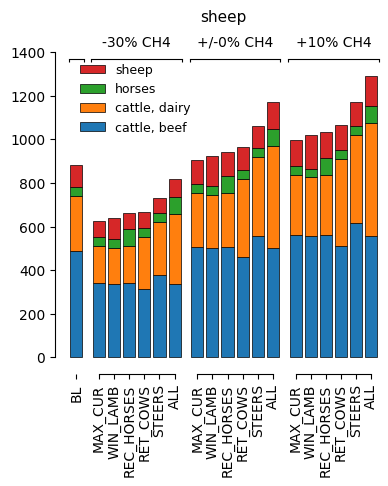

In [17]:
plot_data = (
    session
    .get_attr('a','feed.max_supply_from_crop_group',['crop_group','species','breed'])
    .rename(rename_years)
    .loc[sort,'Semi-natural pastures']
)/1_000_000
plot_data.columns = pd.Index([c[0] if c[0] != 'cattle' else ', '.join(c) for c in plot_data.columns], name='animal_system')
plot_data = plot_data.T.groupby('animal_system').sum().T

fig, ax = plt.subplots(figsize=(4,4))
cm.plot.bar(
    plot_data,
    group_levels='year',
    grouptitle=ani,
    ax=ax
)
plt.show()

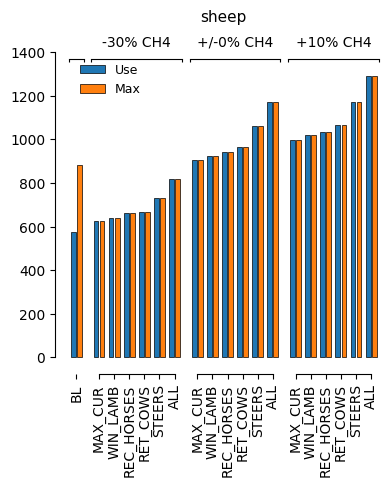

In [18]:
use_df = (
    session.get_attr('c','production', {'crop':'crop_group'})
    .rename(rename_years)
    .loc[sort,'Semi-natural pastures']
    .rename('Use')
)/1_000_000

max_df = (
    session
    .get_attr('a','feed.max_supply_from_crop_group',['crop_group'])
    .rename(rename_years)
    .loc[sort,'Semi-natural pastures']
    .rename('Max')
)/1_000_000

plot_data = pd.concat([use_df,max_df], axis=1)

fig, ax = plt.subplots(figsize=(4,4))
cm.plot.bar(
    plot_data,
    stacked=False,
    group_levels='year',
    grouptitle=ani,
    ax=ax
)
plt.show()

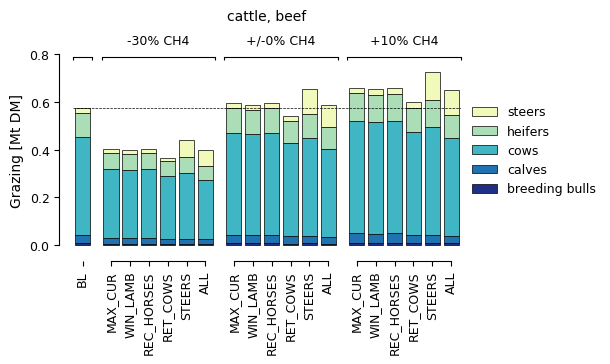

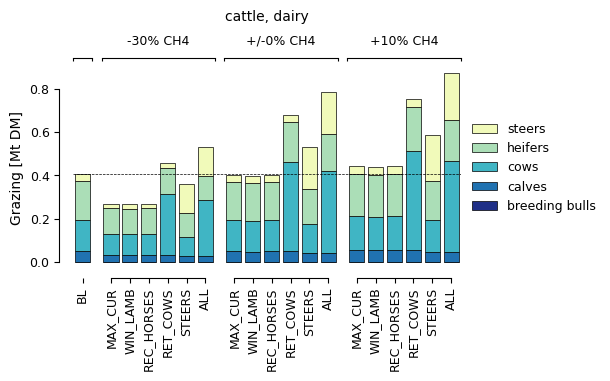

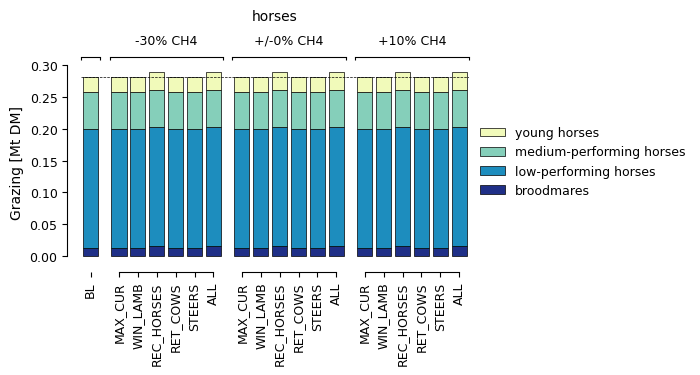

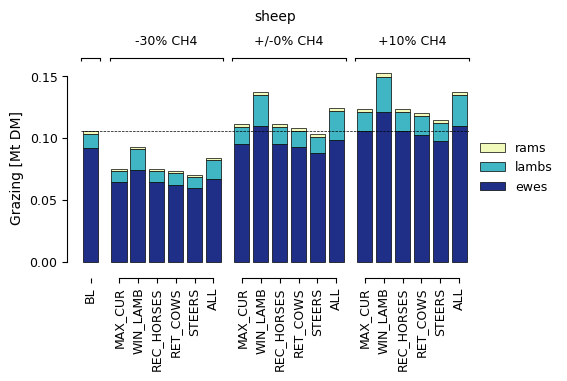

In [19]:
plot_data = (
    session.get_attr('a','feed.crop_prod',['origin','crop_prod','species','breed','animal'])
    .rename(rename_years)
    .loc[sort,('domestic','grazing')]
    .stack(['species','breed'])
)/1_000_000_000
plot_data.index = pd.MultiIndex.from_tuples(
    [( scn, y, sp if sp != 'cattle' else ', '.join([sp,br]) ) for scn,y,sp,br in plot_data.index],
    names = ['scn', 'year', 'animal_system']
)
plot_data = plot_data.groupby(['scn', 'year', 'animal_system'], sort=False).sum()

for ani in plot_data.index.unique('animal_system'):
    fig,ax = plt.subplots(figsize=(5,2.5))
    d = plot_data.xs(ani, level='animal_system').replace({0:np.nan}).dropna(axis=1)
    cm.plot.bar(
        d,
        ax=ax,
        group_levels=['year'],
        sort_groups=False,
        sort_xlabels=False,
        sort_categories=False,
        grouptitle=ani,
        ylabel='Grazing [Mt DM]',
        ticklabels_fontsize=9,
        grouptitle_fontsize=10,
        grouplabels_fontsize=9,
        ylabel_fontsize=10,
        cmap='YlGnBu'
    )
    ax.axhline(d.loc['BL'].sum(axis=1).iloc[0], c='black', linewidth=0.5, linestyle='--')
    ax.legend(loc='center left', bbox_to_anchor=(1,0.5), frameon=False, ncol=1, fontsize=9, reverse=True)
    plt.show()

### Maps: Potential pastures and yield

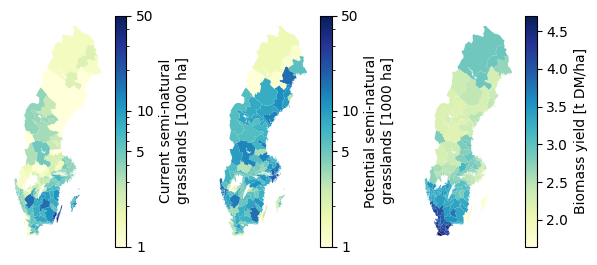

In [26]:
import matplotlib

a0 = session.get_attr('r','x0_crops',{'crop':'land_use', 'region':None}).loc[('BL','0'), 'semi-natural grasslands']/1000
a1 = session.get_attr('r','x0_crops',{'crop':'land_use', 'region':None}).loc[('MAX_CUR','100'), 'semi-natural grasslands']/1000
y = (
    (session.get_attr('c','harvest',{'crop':'land_use','region':None})
    /session.get_attr('c','area',{'crop':'land_use','region':None}))
    .loc[('BL','0'),'semi-natural grasslands']
)/1000

fig, axs = plt.subplots(1,3, figsize=(7.5,3))
ax = axs[0]
cm.plot.map_from_series(a0, cmap='YlGnBu', norm=matplotlib.colors.LogNorm(vmin=1, vmax=50), legend=False, ax=ax)
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('Current semi-natural\ngrasslands [1000 ha]', fontsize=10)
cbar.set_ticks([1,5,10,50])
cbar.set_ticklabels(['1','5','10','50'])
ax.axis('off')

ax = axs[1]
cm.plot.map_from_series(a1-a0, cmap='YlGnBu', norm=matplotlib.colors.LogNorm(vmin=1, vmax=50), legend=False, ax=ax)
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('Potential semi-natural\ngrasslands [1000 ha]', fontsize=10)
cbar.set_ticks([1,5,10,50])
cbar.set_ticklabels(['1','5','10','50'])
ax.axis('off')

ax=axs[2]
cm.plot.map_from_series(y, cmap='YlGnBu', ax=ax, legend=False)
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('Biomass yield [t DM/ha]', fontsize=10)
ax.axis('off')

plt.tight_layout
plt.show()

### Maps: Changes in semi-natural grassland and cropland area

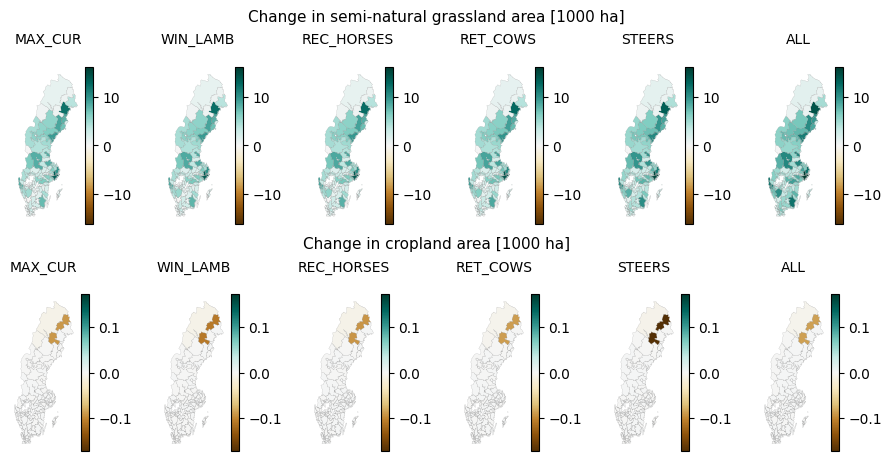

In [21]:
plot_data = (
    session.get_attr('c','area',{'crop':'land_use', 'region':None})
    .loc[scn_final,:]
    .transform(lambda x: x.sub(x.loc[('BL','0')],axis=1))
    .drop(('BL','0'))
    .droplevel('year')
)/1000

scn_sorted = plot_data.sum(axis=1).sort_values().index

n_scn = len(plot_data)
lims = plot_data.T.abs().groupby('land_use').max().max(axis=1)

fig = plt.figure(layout='constrained', figsize=(1.5*n_scn, 4.5))
subfigs = fig.subfigures(2, 1, wspace=0.07)

# Semi-natural grasslands
axs1 = subfigs[0].subplots(1,n_scn)
for n, scn in enumerate(plot_data.sum(axis=1).sort_values().index):
    ax = axs1[n]
    cm.plot.map_from_series(
        plot_data.loc[scn,'semi-natural grasslands'],
        ax = ax,
        vmin=-lims.loc['semi-natural grasslands'],
        # cmap_zero_midpoint='shrink',
        vmax=lims.loc['semi-natural grasslands'],
        **map_style_div
    )
    ax.set_title(scn, size=10)
    ax.axis('off')
subfigs[0].suptitle('Change in semi-natural grassland area [1000 ha]', size=11)

# Cropland
axs2 = subfigs[1].subplots(1,n_scn)
# fig, axs = plt.subplots(1,n_scn, figsize=(2.2*n_scn,4))
for n, scn in enumerate(plot_data.sum(axis=1).sort_values().index):
    ax = axs2[n]
    cm.plot.map_from_series(
        plot_data.loc[scn,'cropland'],
        ax = ax,
        vmin=-lims.loc['cropland'],
        # cmap_zero_midpoint='shrink',
        vmax=lims.loc['cropland'],
        **map_style_div
    )
    ax.set_title(scn, size=10)
    ax.axis('off')
subfigs[1].suptitle('Change in cropland area [1000 ha]', size=11)

# fig.tight_layout()
plt.show()

(<Axes: >,
 [<Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>])

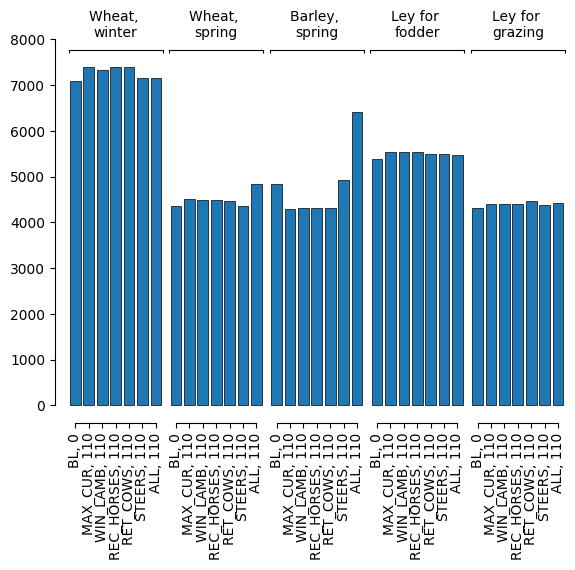

In [27]:
d=(
    (
    session.get_attr('c','harvest',{'crop':None}) /
    session.get_attr('c','area',{'crop':None})
    )
    .loc[scn_final,['Wheat, winter','Wheat, spring', 'Barley, spring', 'Ley for fodder', 'Ley for grazing']]
    .loc[sort.unique('scn')]
    .stack()
)

cm.plot.bar(d, group_levels='crop')

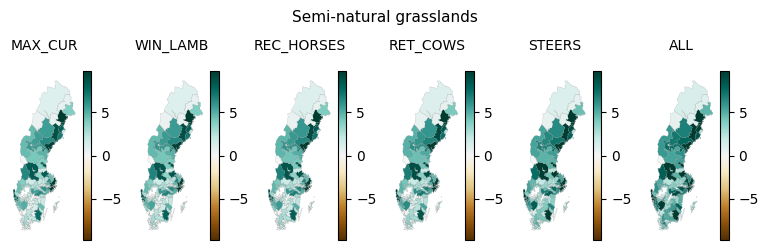

,0,1
scn,,
MAX_CUR,327.2,419.7
WIN_LAMB,342.4,441.9
REC_HORSES,353.6,458.1
RET_COWS,375.6,490.3
STEERS,447.6,596.0
ALL,528.3,714.7


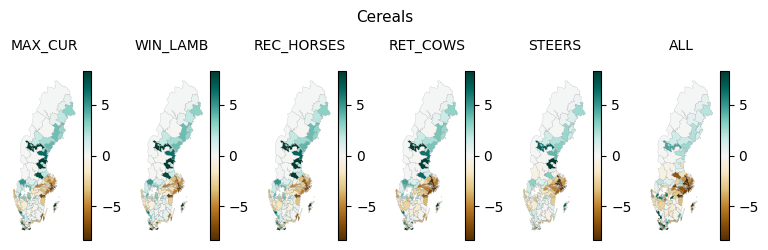

,0,1
scn,,
MAX_CUR,30.1,-7.6
WIN_LAMB,27.8,-21.6
REC_HORSES,36.6,-6.5
RET_COWS,-4.7,-83.9
STEERS,-41.2,-238.9
ALL,-53.8,-301.7


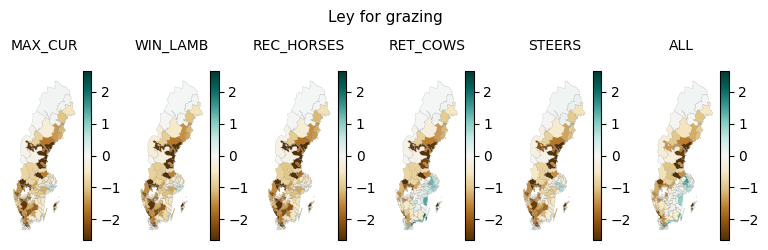

,0,1
scn,,
MAX_CUR,-107.6,-278.6
WIN_LAMB,-109.9,-284.4
REC_HORSES,-118.9,-309.6
RET_COWS,-47.9,-104.3
STEERS,-98.5,-255.1
ALL,-55.8,-131.6


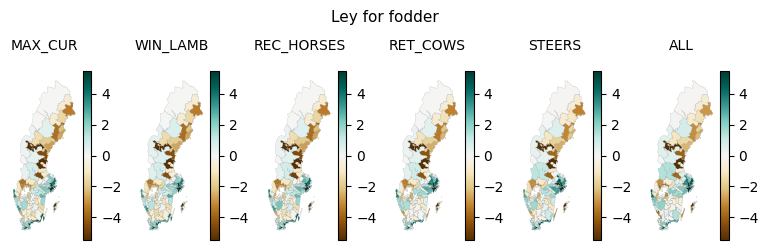

,0,1
scn,,
MAX_CUR,-6.4,78.5
WIN_LAMB,-3.0,96.2
REC_HORSES,-7.8,66.6
RET_COWS,-13.2,5.2
STEERS,6.3,116.2
ALL,-6.6,29.2


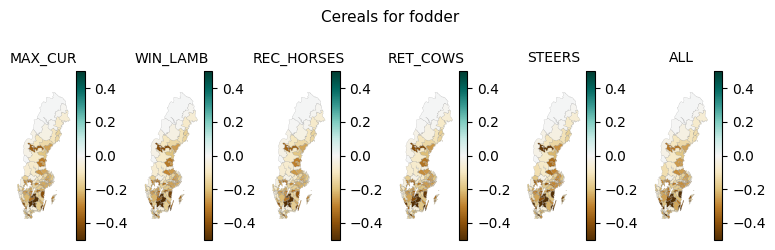

,0,1
scn,,
MAX_CUR,-21.0,-70.7
WIN_LAMB,-22.2,-74.9
REC_HORSES,-20.5,-68.9
RET_COWS,-23.3,-78.8
STEERS,-25.1,-85.1
ALL,-24.3,-83.5


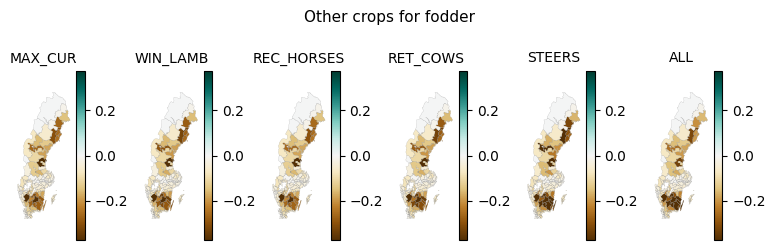

,0,1
scn,,
MAX_CUR,-11.2,-45.7
WIN_LAMB,-11.9,-48.7
REC_HORSES,-11.0,-44.7
RET_COWS,-12.1,-49.7
STEERS,-14.7,-61.3
ALL,-13.6,-57.7


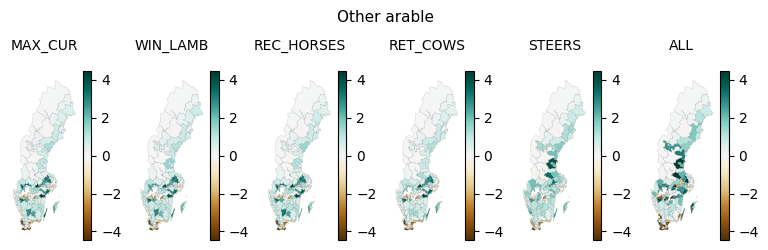

,0,1
scn,,
MAX_CUR,51.6,67.4
WIN_LAMB,54.1,65.9
REC_HORSES,56.2,69.2
RET_COWS,41.4,46.2
STEERS,78.0,55.1
ALL,73.0,33.5


In [22]:
d1 = (
    session.get_attr('c','area',{'crop':'crop_group2', 'region':None})
    .loc[scn_final,:]
    .transform(lambda x: x.sub(x.loc[('BL','0')],axis=1))
    .drop(('BL','0'))
    .droplevel('year')
)/1_000

d2 = (
    session.get_attr('c','area',{'crop':None, 'region':None})
    .loc[scn_final,:]
    .transform(lambda x: x.sub(x.loc[('BL','0')],axis=1))
    .drop(('BL','0'))
    .droplevel('year')
)/1_000

d3 = (
    session.get_attr('c','production',{'crop':'crop_group2', 'region':None})
    .loc[scn_final,:]
    .transform(lambda x: x.sub(x.loc[('BL','0')],axis=1))
    .drop(('BL','0'))
    .droplevel('year')
)/1_000_000

d4 = (
    session.get_attr('c','production',{'crop':None, 'region':None})
    .loc[scn_final,:]
    .transform(lambda x: x.sub(x.loc[('BL','0')],axis=1))
    .drop(('BL','0'))
    .droplevel('year')
)/1_000_000

s = d1.loc[:,'Semi-natural grasslands'].sum(axis=1).sort_values().index
d1 = d1.loc[s]
d2 = d2.loc[s]
d3 = d3.loc[s]
d4 = d4.loc[s]

n_scn = len(d1)

crps = ['Semi-natural grasslands','Cereals','Ley for grazing','Ley for fodder','Cereals for fodder','Other crops for fodder','Other arable']

for crp in crps:
    try:
        d = d1.loc[:,crp]
        p = d3.loc[:,crp]
    except KeyError:
        d = d2.loc[:,crp]
        p = d4.loc[:,crp]
    lim = np.quantile(d.abs(),0.95)
    
    fig, axs = plt.subplots(1,n_scn, figsize=(1.3*n_scn,2.5))
    for i, scn in enumerate(d.index):
        ax=axs[i]
        cm.plot.map_from_series(
            d.loc[scn],
            ax=ax,
            vmin=-lim,
            vmax=lim,
            **map_style_div
        )
        ax.set_title(scn, size=10)
        ax.axis('off')
    plt.suptitle(f'{crp}', size=11)
    plt.tight_layout()
    plt.show()
    display(pd.concat([d.sum(axis=1),p.sum(axis=1)], axis=1).style.format(precision=1))


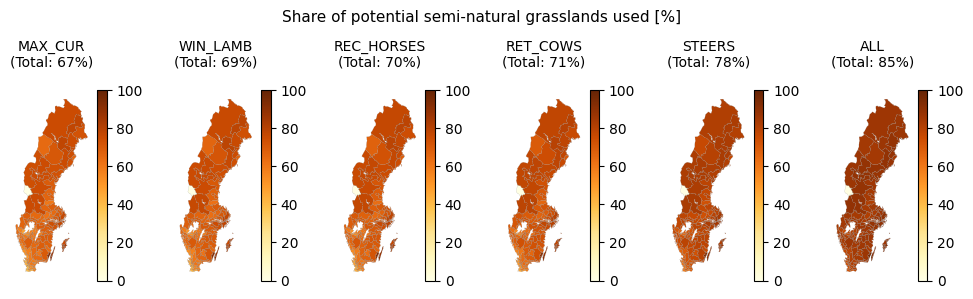

In [23]:
sng_use = session.get_attr('c','area',{'crop':'land_use', 'region':None}).loc[scn_final,'semi-natural grasslands']
sng_pot = session.get_attr('r','max_land_use',['land_use','region']).loc[scn_final,'semi-natural grasslands']
tot_share = (sng_use.sum(axis=1) / sng_pot.sum(axis=1)).droplevel('year')*100

plot_data = (
    (sng_use / sng_pot)
    .drop('BL', level='scn')
    .droplevel('year')
) * 100
scn_sorted = plot_data.sum(axis=1).sort_values().index

fig, axs = plt.subplots(1,len(plot_data), figsize=(10,3))
for n, scn in enumerate(scn_sorted):
    ax = axs[n]
    cm.plot.map_from_series(
        plot_data.loc[scn],
        ax = ax,
        vmin=0,
        vmax=100,
        **map_style
    )
    ax.set_title(f'{scn}\n(Total: {tot_share.loc[scn]:.0f}%)', size=10)
    ax.axis('off')
fig.suptitle('Share of potential semi-natural grasslands used [%]', size=11)
plt.tight_layout()
plt.show()

### Maps. Changes in animal herds

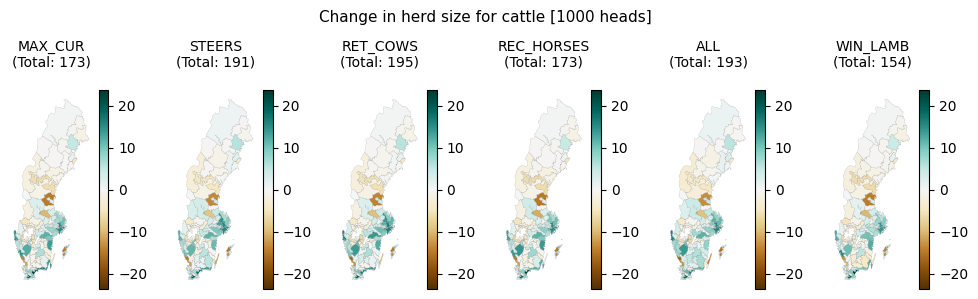

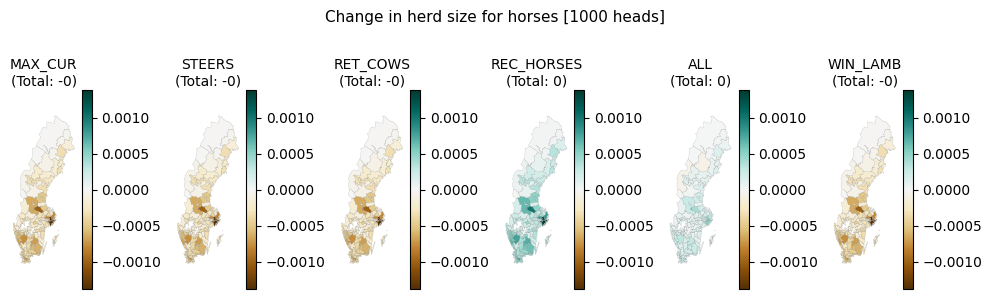

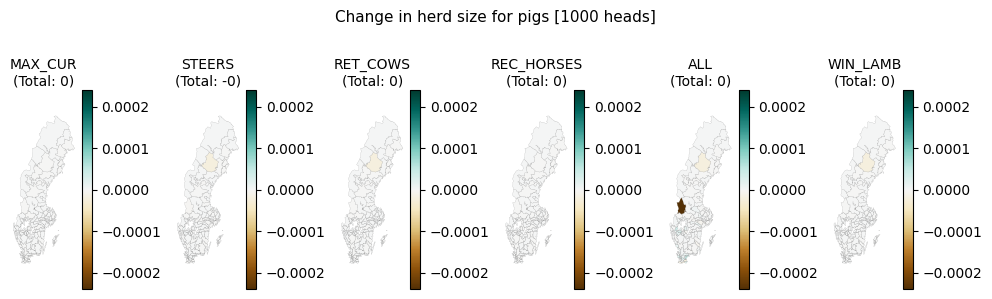

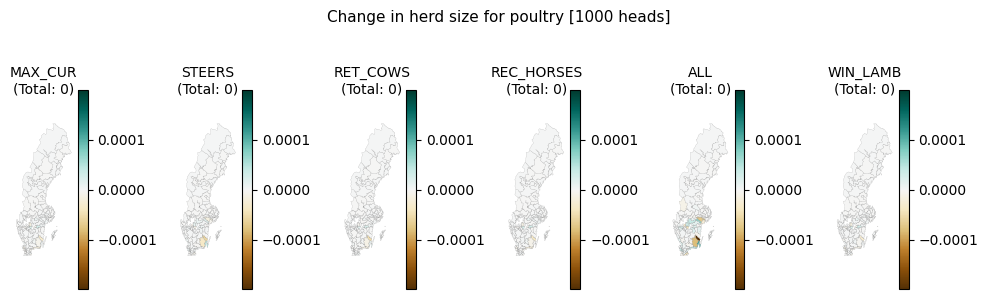

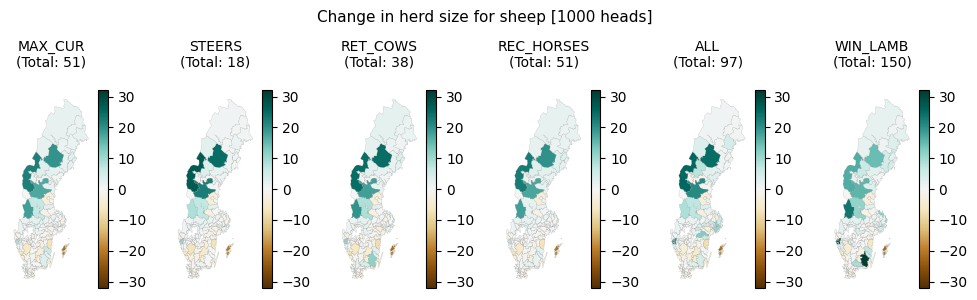

In [28]:
plot_data = (
    session.get_attr('a','heads',['region','species'])
    .loc[scn_final]
    .droplevel('year')
    .transform(lambda x: x.sub(x.loc[('BL')],axis=1))
    .drop('BL')
    .stack('region')
)/1000
# plot_data.columns = pd.Index([c[0] if c[0] != 'cattle' else ', '.join(c) for c in plot_data.columns], name='animal_system')
# plot_data = plot_data.T.groupby('animal_system').sum().T



for ani in plot_data.columns:
    d = plot_data.loc[:,ani]

    lim = max(-min(d.values), max(d.values))
    
    fig, axs = plt.subplots(1,len(d.index.unique('scn')), figsize=(10,3))
    for n, scn in enumerate(d.index.unique('scn')):
        ax = axs[n]
        cm.plot.map_from_series(
            d.loc[scn],
            ax = ax,
            vmin = -lim,
            vmax = lim,
            **map_style_div
        )
        ax.set_title(f'{scn}\n(Total: {d.loc[scn].sum():.0f})', size=10)
        ax.axis('off')
    fig.suptitle(f'Change in herd size for {ani} [1000 heads]', size=11)
    plt.tight_layout()
    plt.show()

## Run scenarios (multi proc.)

In [4]:
# Import
from concurrent.futures import ProcessPoolExecutor, as_completed
from multi_proc import do_run

In [6]:
# Create list of scenarios to run
runs = [(s,y) for s,y in session.iterate('all')]
runs

[('BL', '0'),
 ('MAX_CUR', '70'),
 ('MAX_CUR', '100'),
 ('MAX_CUR', '110'),
 ('STEERS', '70'),
 ('STEERS', '100'),
 ('STEERS', '110'),
 ('RET_COWS', '70'),
 ('RET_COWS', '100'),
 ('RET_COWS', '110'),
 ('REC_HORSES', '70'),
 ('REC_HORSES', '100'),
 ('REC_HORSES', '110'),
 ('ALL', '70'),
 ('ALL', '100'),
 ('ALL', '110'),
 ('WIN_LAMB', '70'),
 ('WIN_LAMB', '100'),
 ('WIN_LAMB', '110')]

In [7]:
%%time
# Do the multi-processing
with ProcessPoolExecutor(max_workers=8) as executor:
    
    futures = {executor.submit(do_run, scn_year) : scn_year for scn_year in runs}

    for future in as_completed(futures):
    
        scn, year = futures[future]
           
        try:
            t = future.result()
        except Exception as ee:
            print(f'(!!!) {scn}, {year} failed with the exception: {ee}')
        else: 
            m = int(t/60)
            s = int(round(t - m*60))
            print(f'{scn}, {year} finished successfully in {m}min {s}s')
            
session.cache.clear()

BL, 0 finished successfully in 4min 12s
STEERS, 70 finished successfully in 4min 28s
STEERS, 110 finished successfully in 4min 42s
MAX_CUR, 110 finished successfully in 4min 45s
RET_COWS, 70 finished successfully in 4min 49s
MAX_CUR, 100 finished successfully in 4min 53s
STEERS, 100 finished successfully in 4min 57s
MAX_CUR, 70 finished successfully in 5min 1s
RET_COWS, 100 finished successfully in 2min 29s
RET_COWS, 110 finished successfully in 4min 6s
REC_HORSES, 110 finished successfully in 4min 33s
REC_HORSES, 100 finished successfully in 4min 53s
ALL, 70 finished successfully in 4min 52s
REC_HORSES, 70 finished successfully in 5min 1s
ALL, 110 finished successfully in 4min 48s
ALL, 100 finished successfully in 4min 54s
WIN_LAMB, 70 finished successfully in 3min 23s
WIN_LAMB, 100 finished successfully in 2min 4s
WIN_LAMB, 110 finished successfully in 1min 48s
CPU times: total: 0 ns
Wall time: 12min 13s


## Run scenarios here

In [5]:
import sys
import os
import time
from contextlib import redirect_stdout, redirect_stderr
import numpy as np
import scipy
import cvxpy
import matplotlib.pyplot as plt
sys.path.insert(0, 'C:/Users/jnka0003/Git repos/CIBUSmod')
import CIBUSmod as cm
from CIBUSmod.utils.helpers import check_constraints

In [6]:
# Create session (Make sure that name and data_path match the notebook!)
session = cm.Session(
    name = 'FORMAS',
    data_path = 'C:\\Users/jnka0003/Git repos/CIBUSmod/data',
    data_path_scenarios = 'scenarios',
    data_path_output = 'output',
    timeout = 60 # Increase timeout to avoid failing to write if multiple processes try to write at the same time
)

In [7]:
# Instatiate Regions
regions = cm.Regions(
    par = cm.ParameterRetriever('Regions'),
    settings = {'max_land_use_from_scenario_x0' : True}
)

# Instantiate DemandAndConversions
demand = cm.DemandAndConversions(
    par = cm.ParameterRetriever('DemandAndConversions')
)

# Instantiate CropProduction
crops = cm.CropProduction(
    par = cm.ParameterRetriever('CropProduction'),
    index = regions.data_attr.get('x0_crops').index
)    

# Instantiate AnimalHerds
# Each AnimalHerd object is stored in an indexed pandas.Series
herds = cm.make_herds(regions)

# Instantiate WasteAndCircularity
waste = cm.WasteAndCircularity(
    demand = demand,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('WasteAndCircularity')
)

# Instantiate WasteAndCircularity
waste = cm.WasteAndCircularity(
    demand = demand,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('WasteAndCircularity')
)

# Instantiate feed management
feed_mgmt = cm.FeedMgmt(
    herds = herds,
    par = cm.ParameterRetriever('FeedMgmt')
)

# Instantiate by-product management
byprod_mgmt = cm.ByProductMgmt(
    demand = demand,
    herds = herds,
    par = cm.ParameterRetriever('ByProductMgmt')
)

# Instantiate manure management
manure_mgmt = cm.ManureMgmt(
    herds = herds,
    feed_mgmt = feed_mgmt,
    par = cm.ParameterRetriever('ManureMgmt'),
    settings = {
        'NPK_excretion_from_balance' : True
    }
)

# Instantiate crop residue managment
crop_residue_mgmt = cm.CropResidueMgmt(
    demand = demand,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('CropResidueMgmt')
)

# Instantiate plant nutrient management
plant_nutrient_mgmt = cm.PlantNutrientMgmt(
    demand = demand,
    regions = regions,
    crops = crops,
    waste = waste,
    herds = herds,
    par = cm.ParameterRetriever('PlantNutrientMgmt')
)

# Instatiate machinery and energy management
machinery_and_energy_mgmt  = cm.MachineryAndEnergyMgmt(
    regions = regions,
    crops = crops,
    waste = waste,
    herds = herds,
    par = cm.ParameterRetriever('MachineryAndEnergyMgmt')
)

# Instatiate inputs management
inputs = cm.InputsMgmt(
    demand = demand,
    crops = crops,
    waste = waste,
    herds = herds,
    par = cm.ParameterRetriever('InputsMgmt')
)

# Instantiate geo distributor
geodist = cm.GeoDistributor(
    regions = regions,
    demand = demand,
    crops = crops,
    herds = herds,
    feed_mgmt = feed_mgmt,
    par = cm.ParameterRetriever('GeoDistributor')
)

In [9]:
def _max_sng_obj(geodist):
    geodist.define_cvx_problem()

    # Get x variable
    x = geodist.problem.variables()[0]

    # Create objective
    rel = cm.ParameterRetriever.get_rel('crop','land_use')
    P = np.concatenate([
        np.zeros(len(geodist.x_idx_short['ani'])),
        np.array([1 if rel[cr] == 'semi-natural grasslands' else 0 for cr,_,_ in geodist.x_idx_short['crp']])
    ])
    obj = cvxpy.Maximize(
        cvxpy.sum(cvxpy.multiply(P, x))
    )
    
    # Create problem
    geodist.problem = cvxpy.Problem(
        objective = obj,
        constraints = geodist.problem.constraints
    )

In [10]:
def _make_ani_cons(geodist, name, M, b, rel):
    
    from CIBUSmod.optimisation.geo_dist import IndexedMatrix
    
    # Create A matrix
    M = scipy.sparse.csc_matrix(M)
    Z = scipy.sparse.csc_matrix((M.shape[0],len(geodist.x_idx_short['crp']))) # Zero matrix
    A = scipy.sparse.hstack([M,Z], format='csc')
    A = IndexedMatrix(
        matrix=A,
        row_idx=pd.Index([name]),
        col_idx={k:v.copy() for k,v in geodist.x_idx_short.items()}
    )
    
    # Append constraint
    geodist.constraints.update({f'{name}: A @ x {rel} b' : {
        'left' : lambda x,A: A.M @ x,
        'right' : lambda A: b,
        'rel' : rel,
        'pars' : {'A':A}
    }})

    return None

In [11]:
def _get_herds_par(herds, attr):
    
    res = pd.concat([
        pd.concat({h.species: 
            pd.concat({h.breed:
                pd.concat({h.prod_system:
                    pd.concat({h.sub_system:
                        h.data_attr.get(attr)
                    }, names=['sub_system'])
                }, names=['prod_system'])
            }, names=['breed'])
        }, names=['species'])
    for h in herds])

    return res

In [12]:
def _make_CH4_cons(geodist, feed_mgmt, baseline_CH4, factor):
    
    feed_mgmt.calculate2()
    
    # Get CH4 emissions per defining animal
    CH4 = _get_herds_par(herds, 'enteric_methane').sum(axis=1).reindex(geodist.x_idx_short['ani'])
    
    # Assert that indexes match
    assert (CH4.index == geodist.x_idx_short['ani']).all()
    
    _make_ani_cons(geodist, name='CH4', M=CH4, b=baseline_CH4 * factor, rel='<=')

    return None

In [13]:
def _make_milkmeat_cons(geodist, baseline_milkmeat):

    # Get milk and meat prod. per defining animal
    meat = _get_herds_par(herds, 'production').xs('meat', level='animal_prod', axis=1).sum(axis=1).xs('cattle', drop_level=False).reindex(geodist.x_idx_short['ani'], fill_value=0)
    milk = _get_herds_par(herds, 'production').xs('milk', level='animal_prod', axis=1).sum(axis=1).xs('cattle', drop_level=False).reindex(geodist.x_idx_short['ani'], fill_value=0)
    milkmeat = (milk - meat*baseline_milkmeat)
    _make_ani_cons(geodist, name='milk/meat', M=milkmeat, b=0, rel='==')

    return None

In [14]:
def _make_beeflamb_cons(geodist, baseline_beeflamb):

    # Get beef and lamb prod. per defining animal
    beef = _get_herds_par(herds, 'production').xs('meat', level='animal_prod', axis=1).sum(axis=1).xs('cattle', drop_level=False).reindex(geodist.x_idx_short['ani'], fill_value=0)
    lamb = _get_herds_par(herds, 'production').xs('meat', level='animal_prod', axis=1).sum(axis=1).xs('sheep', drop_level=False).reindex(geodist.x_idx_short['ani'], fill_value=0)
    beeflamb = (beef - lamb*baseline_beeflamb)
    _make_ani_cons(geodist, name='beef/lamb', M=beeflamb, b=0, rel='==')

    return None

In [15]:
# Create list of scenarios to run
runs = [(s,y) for s,y in session.iterate('cur')]
runs

[('cur', '70'), ('cur', '100'), ('cur', '110')]

In [ ]:
for scn, year in runs:
    
    tic = time.time()
    scn_str = f'Scenario: {scn}, {year}'
    print(f'\n{"-"*len(scn_str)}\n{scn_str}\n{"-"*len(scn_str)}\n')
    
    # Update all parameter values
    cm.ParameterRetriever.update_all_parameter_values(
        **session[scn],
        year = year
    )
    
    # Get region attributes
    regions.calculate(verbose=True)
    
    # Calculate food demand
    demand.calculate(verbose=True)
    
    # Calculate crops
    crops.calculate(verbose=True)
    
    # Calculate herds
    for h in herds:
        h.calculate(verbose=True)
    
    # Calculate feed
    feed_mgmt.calculate(verbose=True)
    
    if scn != 'baseline':
        while True:
            try:
                # Get baseline crop areas, animal numbers and land use
                baseline_ani = session.get_attr('geo','x_animals', scn='BL').iloc[0]
                baseline_crp = session.get_attr('geo','x_crops', scn='BL').iloc[0]
                baseline_lu = session.get_attr('c','area',{'region':None, 'crop':'land_use'}, scn='BL').iloc[0].unstack()
                # Get baseline CH4 emissions
                baseline_CH4 = session.get_attr(
                    'A', 'enteric_methane',
                    'none',
                    scn='BL'
                ).iloc[0]
                # Get baseline milk/meat
                prod = session.get_attr('A', 'prod', ['species', 'animal_prod'], scn='BL').iloc[0]
                baseline_milkmeat = prod[('cattle','milk')] / prod[('cattle','meat')]
                # Get baseline beef/lamb
                prod = session.get_attr('A', 'prod', ['species','animal_prod'], scn='BL').iloc[0]
                baseline_beeflamb = prod[('cattle','meat')] / prod[('sheep','meat')]
            except:
                time.sleep(10)
            else:
                break
    
    # Distribute animals and crops
    # Make optimisation problem
    if scn == 'BL':
        geodist.make(
            use_cons=[1,2,3,4,5,6,7],
            scale_power=0.4,
            verbose=True
        )
        # Solve optimisation problem
        geodist.solve(verbose=True)
    else:
        # Drop demand for cattle, sheep and horses
        demand.data_attr.update(
            'animal_prod_demand',
            demand.data_attr.get('animal_prod_demand')
            .loc[(slice(None),['pigs','poultry'],slice(None))]
        )
    
        # Set maximum cropland and greenhouse area to baseline levels
        regions.data_attr.get('max_land_use').update(baseline_lu.loc[:,['cropland','greenhouse']])
    
        # Baseline Semi-natural grassland areas
        C8_SNG_P = baseline_crp.copy()\
        .loc[['Semi-natural pastures']]
        C8_SNG_PWT = baseline_crp.copy()\
        .loc[['Semi-natural pastures, wooded','Semi-natural pastures, thin soils']]
        C8_SNG_M = baseline_crp.copy()\
        .loc[['Semi-natural meadows']]
        C8_FAL = baseline_crp.copy()\
        .loc[['Fallow', 'Ley not harvested']]
        C8_ani = baseline_ani.copy()
    
        geodist.make(
            use_cons=[1,2,3,4,5,6,7,8],
            scale_power=0.4,
            C8_crp = [ C8_SNG_P,   C8_SNG_PWT,   C8_SNG_M,   C8_FAL,   None                                     ],
            C8_ani = [ None,       None,         None,       None,     C8_ani.loc[['horses','pigs','poultry']]  ],
            C8_rel = [ '>=',       '==',         '==',       '>=',     '=='                                     ],
            verbose=True
        )
        
        # Add constraint on CH4 emissions and milk/meat
        CH4_factor = float(year)/100
        _make_CH4_cons(geodist, feed_mgmt, baseline_CH4, CH4_factor)
        _make_milkmeat_cons(geodist, baseline_milkmeat)
        _make_beeflamb_cons(geodist, baseline_beeflamb)
    
        # First we solve while dropping everything from the
        # obejctive except for semi-natural grasslands
        for w in ['ani','crp']:
            for k in geodist.x0_idx[w].unique(0):
                if k not in ['Semi-natural pastures', 'Semi-natural pastures, wooded', 'Semi-natural pastures, thin soils', 'Semi-natural meadows']:
                    cm.helpers.drop_from_objective(geodist, which=w, key=k)
        geodist.solve(apply_solution=False, verbose=True)
    
        # Get semi-natural grassland areas from first solution and add constraint on
        # semi-natural grassland area for second optimization round
        sng_areas = geodist.x['crp'].loc[['Semi-natural pastures', 'Semi-natural pastures, thin soils', 'Semi-natural pastures, wooded']]
        geodist.make_C8(C8_crp = sng_areas, C8_rel = '>=') 
        geodist.make_C7()
    
        # Solve optimisation problem again, this time minimising deviation from current
        # crop areas and animal numbers
        geodist.define_cvx_problem()
        geodist.solve(verbose=True)
    
    # Redistribute feeds (not yet implemented) and calculate enteric CH4 emissions
    feed_mgmt.calculate2(verbose=True)
    
    # Balance by-product demand and suply
    byprod_mgmt.calculate(verbose=True)
    
    # Calculate manure
    manure_mgmt.calculate(verbose=True)
    
    # Calculate harvest of crop residues
    crop_residue_mgmt.calculate(verbose=True)
    
    # Calculate treatment of wastes and other feedstocks
    waste.calculate(verbose=True)
    
    # Calculate plant nutrient management
    plant_nutrient_mgmt.calculate(verbose=True)
    
    # Calculate energy requirements
    machinery_and_energy_mgmt.calculate(verbose=True)
    
    # Calculate inputs supply chain emissions
    inputs.calculate(verbose=True)
    
    # Store results (try again if first atempt fails)
    try:
        session.store(
            scn, year,
            demand, regions, crops, herds, waste, geodist
        )
    except:
        session.store(
            scn, year,
            demand, regions, crops, herds, waste, geodist
        )

    t = time.time() - tic
    m = int(t/60)
    s = int(round(t - m*60))
    print(f'{scn}, {year} finished successfully in {m}min {s}s')

    check_constraints(geodist)
    plt.show()